<a href="https://colab.research.google.com/github/asozykin/nii-simulation/blob/main/Net_income_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("https://docs.google.com/spreadsheets/d/1KLuP4270AetJjs6ja8n9qjTmM11dYmWFvR2AyIWGZ9k/export?format=csv")

def read_yield_curves(csv_url: str) -> pd.DataFrame:
    """
    Reads yield curve data from a public Google Sheets CSV export.

    Expects:
      - First column: tenor labels (e.g. '1D', '1M', '10Y', '10Y+')
      - Remaining columns: one yield curve each (13 total), with rates as values
      - First row: header row naming each curve

    Returns:
      A DataFrame indexed by tenor, with one column per yield curve.
      Values are floats representing rates.
    """
    df = pd.read_csv(csv_url, index_col=0)

    # Clean up column names (in case of blank/odd headers) and tenor index
    df.columns = [str(c).strip() for c in df.columns]
    df.index = [str(i).strip() for i in df.index]
    df.index.name = "tenor"

    # Ensure rates are numeric
    df = df.apply(pd.to_numeric, errors="coerce")

    return df


def get_curve(df: pd.DataFrame, curve_name: str) -> pd.Series:
    """Returns a single yield curve (tenor -> rate) as a Series."""
    if curve_name not in df.columns:
        raise KeyError(f"Curve '{curve_name}' not found. Available: {list(df.columns)}")
    return df[curve_name]


# Example usage
if __name__ == "__main__":
    url = "https://docs.google.com/spreadsheets/d/1KLuP4270AetJjs6ja8n9qjTmM11dYmWFvR2AyIWGZ9k/export?format=csv"
    curves = read_yield_curves(url)

    print(curves.head())
    print(curves.columns.tolist())  # the 13 curve names

    one_curve = get_curve(curves, "1M")
    print(one_curve)

           0     1M     2M     3M     4M     5M     6M     7M     8M     9M  \
tenor                                                                         
1D     12.43  11.93  11.93  11.68  11.68  11.68  11.43  11.43  11.43  11.43   
1M     12.51  12.01  12.01  11.76  11.76  11.76  11.51  11.51  11.51  11.51   
2M     12.59  12.09  12.09  11.84  11.84  11.84  11.59  11.59  11.59  11.59   
3M     12.81  12.31  12.31  12.06  12.06  12.06  11.81  11.81  11.81  11.81   
6M     13.01  12.51  12.51  12.26  12.26  12.26  12.01  12.01  12.01  12.01   

         10M    11M    12M  
tenor                       
1D     11.43  11.43  10.93  
1M     11.51  11.51  11.01  
2M     11.59  11.59  11.09  
3M     11.81  11.81  11.31  
6M     12.01  12.01  11.51  
['0', '1M', '2M', '3M', '4M', '5M', '6M', '7M', '8M', '9M', '10M', '11M', '12M']
tenor
1D      11.93
1M      12.01
2M      12.09
3M      12.31
6M      12.51
9M      12.80
1Y      13.04
18M     13.41
2Y      14.11
3Y      13.94
5Y      14.10
10

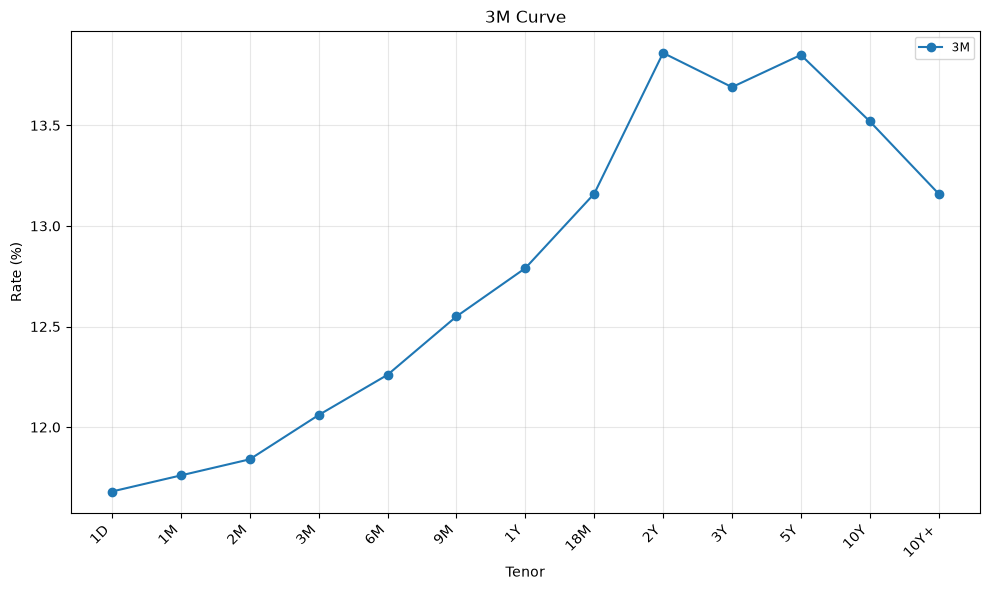

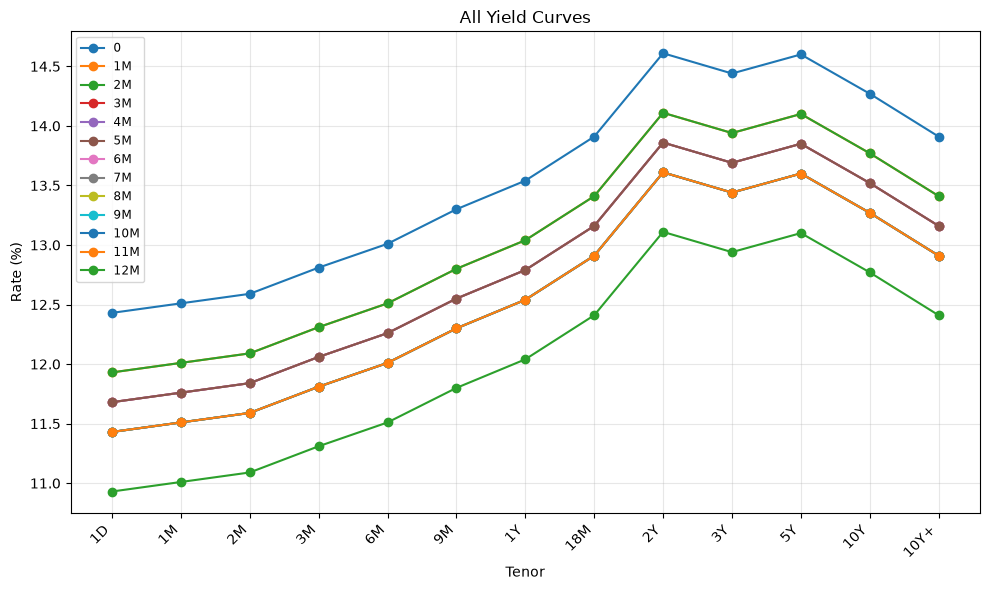

In [2]:

import re
import matplotlib.pyplot as plt


def tenor_to_days(tenor: str) -> float:
    """
    Converts a tenor label to an approximate number of days, for sorting/plotting.
    Handles D (days), M (months), Y (years), and a trailing '+' (e.g. '10Y+').
    """
    tenor = tenor.strip().upper()
    match = re.match(r"(\d+(?:\.\d+)?)([DMY])(\+)?", tenor)
    if not match:
        raise ValueError(f"Unrecognized tenor format: {tenor}")

    value, unit, plus = match.groups()
    value = float(value)

    unit_days = {"D": 1, "M": 30, "Y": 365}
    days = value * unit_days[unit]

    if plus:
        days += 1  # nudge '10Y+' just past '10Y' so it sorts after it

    return days


def plot_yield_curves(df, curve_names=None, ax=None, title="Yield Curves"):
    """
    Plots one or more yield curves from the DataFrame returned by read_yield_curves().

    Args:
        df: DataFrame indexed by tenor, one column per curve (from read_yield_curves).
        curve_names: list of column names to plot. If None, plots all curves.
        ax: optional matplotlib Axes to plot on. If None, creates a new figure.
        title: plot title.

    Returns:
        The matplotlib Axes used for the plot.
    """
    if curve_names is None:
        curve_names = list(df.columns)

    # Sort tenors chronologically rather than alphabetically
    sorted_tenors = sorted(df.index, key=tenor_to_days)
    df_sorted = df.loc[sorted_tenors]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    for name in curve_names:
        if name not in df_sorted.columns:
            raise KeyError(f"Curve '{name}' not found. Available: {list(df.columns)}")
        ax.plot(df_sorted.index, df_sorted[name], marker="o", label=name)

    ax.set_xlabel("Tenor")
    ax.set_ylabel("Rate (%)")
    ax.set_title(title)
    ax.legend(loc="best", fontsize="small")
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    if ax.figure is not None:
        ax.figure.tight_layout()

    return ax


# Example usage
if __name__ == "__main__":
    url = "https://docs.google.com/spreadsheets/d/1KLuP4270AetJjs6ja8n9qjTmM11dYmWFvR2AyIWGZ9k/export?format=csv"
    curves = read_yield_curves(url)

    # Plot a single curve
    plot_yield_curves(curves, curve_names=["3M"], title="3M Curve")
    plt.show()

    # Plot all 13 curves together
    plot_yield_curves(curves, title="All Yield Curves")
    plt.show()